## Exploratory Data Analysis: NY Workers' Compensation Claims 2000–2025


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

sns.set_style("darkgrid")
mpl.rcParams['figure.figsize'] = (20, 5)

WC_data_clean = pd.read_csv('WC_data_clean.csv')

### OVERVIEW

This analysis examines which demographic, industry, and claim-related characteristics are associated with higher hearing counts in New York workers' compensation claims filed between 2000 and 2025.

### 1. Demographic Characteristics
This issue explores whether claimant demographic factors are associated with higher hearing counts.

- **Age at Injury**
- **Gender**
- **Location**

#### 1.1 Age at Injury
Does age at injury relate to the number of hearings?

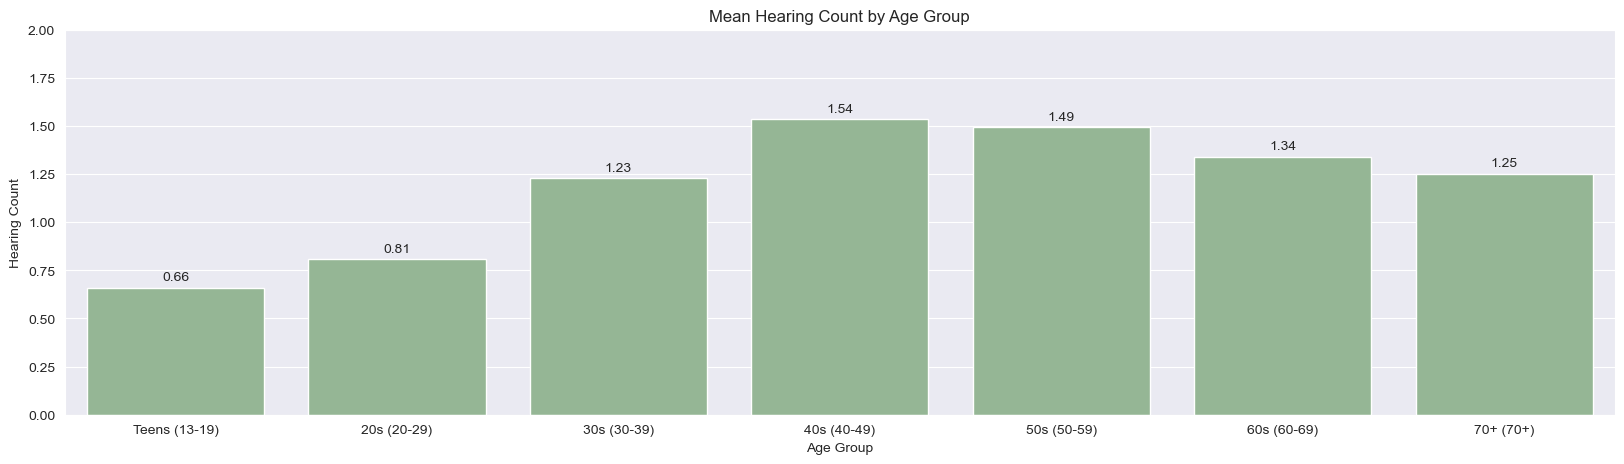

In [4]:
age_order = ['Teens (13-19)', '20s (20-29)', '30s (30-39)', '40s (40-49)', '50s (50-59)', '60s (60-69)', '70+ (70+)']

sns.barplot(data=WC_data_clean, x='Age Group', 
            y='Hearing Count', 
            order=age_order,
           errorbar= None,
           color='darkseagreen')
plt.title('Mean Hearing Count by Age Group')
plt.ylim(0,2)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.show()


Workers in their 40s have the highest average hearing count (1.5), while teenagers have the lowest (0.66). Hearing frequency generally increases with age before declining in older groups.

#### 1.2 Gender
Are there differences in hearing counts by **gender**?

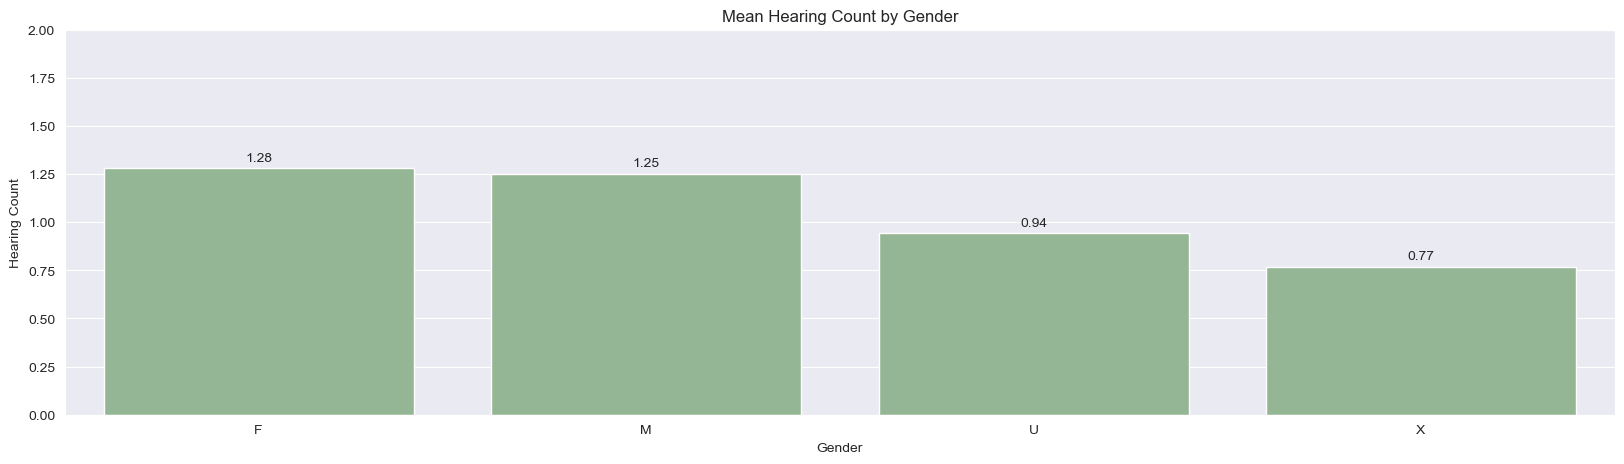

In [5]:
gender_order=['F','M','U','X']

sns.barplot(data=WC_data_clean, x='Gender', 
            y='Hearing Count',
            order= gender_order,
            errorbar = None,
            color='darkseagreen')
plt.title('Mean Hearing Count by Gender')
plt.ylim(0,2)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()
        

Hearing counts are nearly identical between female (1.28) and male (1.25) claimants, suggesting gender has little to no relationship with the number of hearings. Unknown (U) and non-binary (X) claimants show slightly lower averages, though these groups are likely too small to draw meaningful conclusions from.

#### 1.3 Location
Does location influence how many hearings a claim receives?

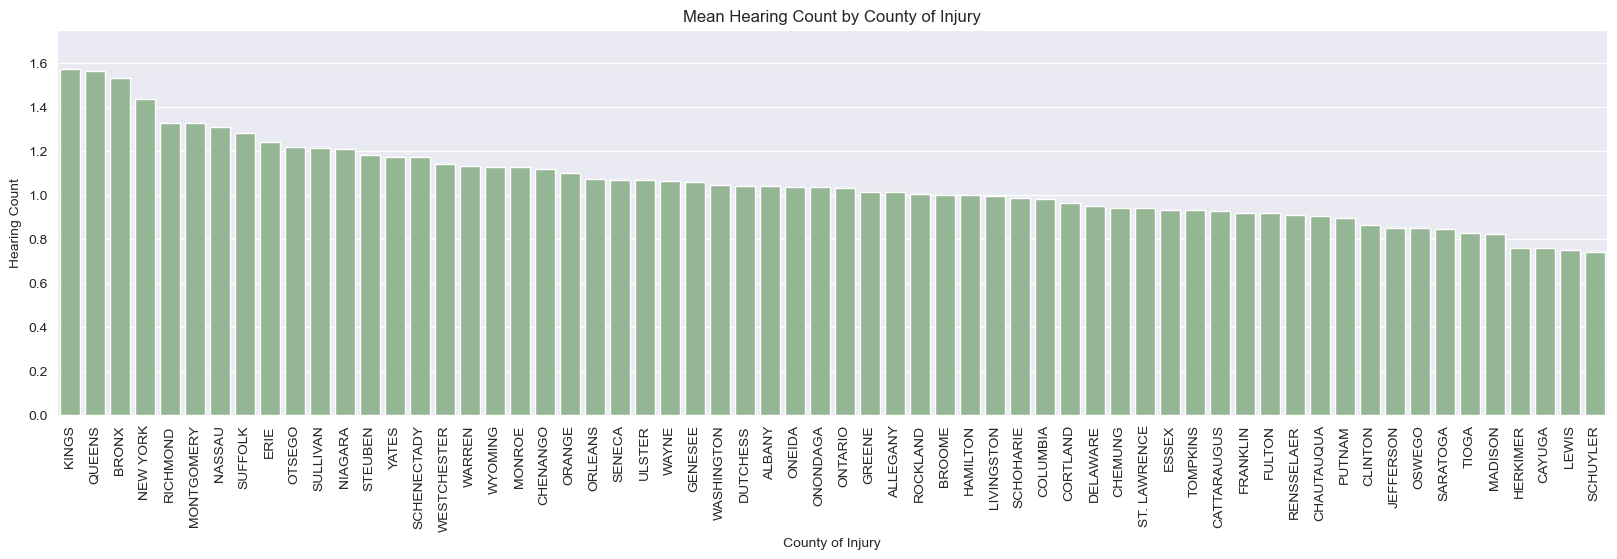

In [6]:
county_order = WC_data_clean[WC_data_clean['County of Injury'] != 'UNKNOWN'].groupby('County of Injury')['Hearing Count'].mean().sort_values(ascending=False).index

sns.barplot(data=WC_data_clean[WC_data_clean['County of Injury'] != 'UNKNOWN'], 
            x='County of Injury',
            y='Hearing Count',
            errorbar=None,
            color='darkseagreen',
            order=county_order)

plt.xticks(rotation=90)
plt.title('Mean Hearing Count by County of Injury')
plt.ylim(0,1.75)

plt.show()

Hearing counts vary by county, with Kings, Queens, and Bronx averaging the highest (1.5+) and rural upstate counties like Schuyler, Lewis, and Cayuga averaging the lowest (0.7)

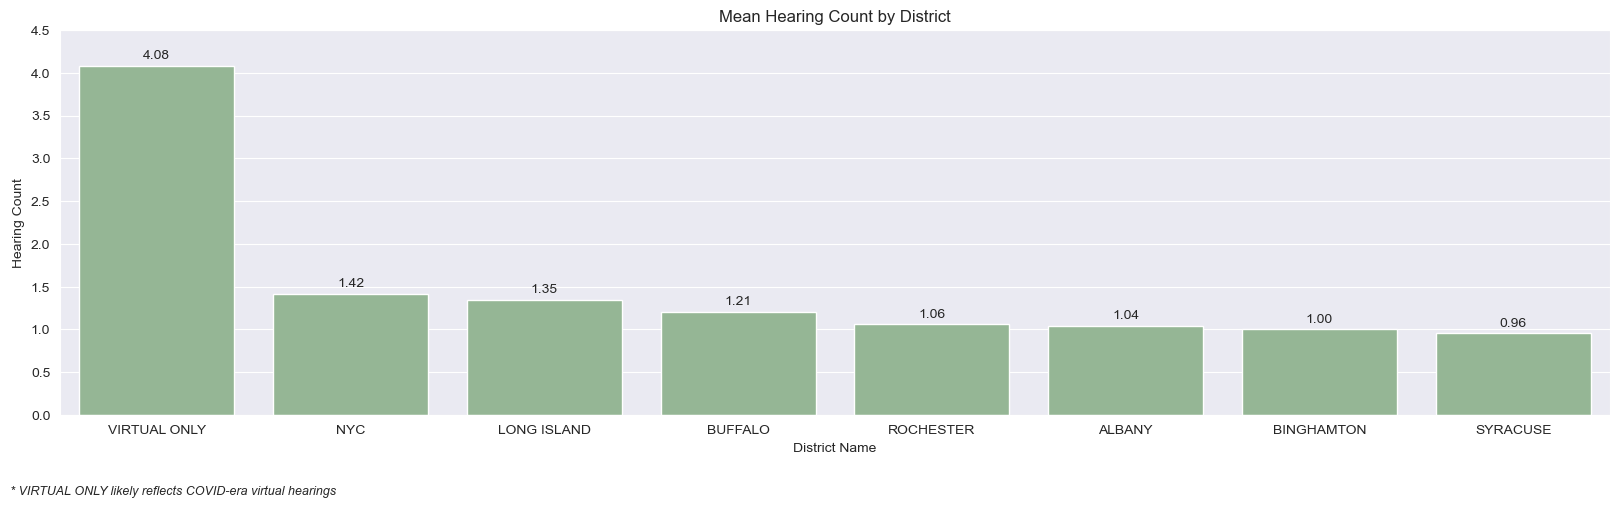

In [7]:
district_order = WC_data_clean.groupby('District Name')['Hearing Count'].mean().sort_values(ascending=False).index

sns.barplot(data=WC_data_clean, x='District Name', y='Hearing Count',
            errorbar=None, color='darkseagreen', order=district_order)

plt.title('Mean Hearing Count by District')
plt.ylim(0, 4.5)
plt.figtext(0.1, -0.05, '* VIRTUAL ONLY likely reflects COVID-era virtual hearings', fontsize=9, style='italic')

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

Districts show moderate variation in mean hearing counts. Excluding the VIRTUAL ONLY district, NYC (1.42) and Long Island (1.35) average the most hearings, while Syracuse (0.96) and Binghamton (1.00) average the fewest. The gap between highest and lowest is relatively small, suggesting district location has a modest but present effect on hearing counts.

### Demographic Characteristics Summary
Demographic factors show varying degrees of association with hearing counts. Age appears to have the strongest relationship, with claims peaking in the 40s (1.54) and declining for younger and older workers. Gender shows minimal difference, with female (1.28) and male (1.25) claimants averaging nearly identical hearing counts. Location shows moderate variation, with NYC and Long Island districts averaging the most hearings and upstate districts the fewest, a pattern consistent at the county level where Kings, Queens, and Bronx lead and rural counties trail.

### 2. Industry Characteristics
This issue explores whether the claimant's industry is associated with higher hearing counts.

- **Industry Codes / Industry Descriptions** 
- **Unknown or missing Industry Classification**


#### 2.1 Industry Codes / Industry Descriptions 
- Do claims from certain industry codes / industry descriptions have higher hearing counts?
- 
#### 2.2 Unknown or missing Industry Classification
- Does an unknown or missing industry classification relate to increased hearing activity?

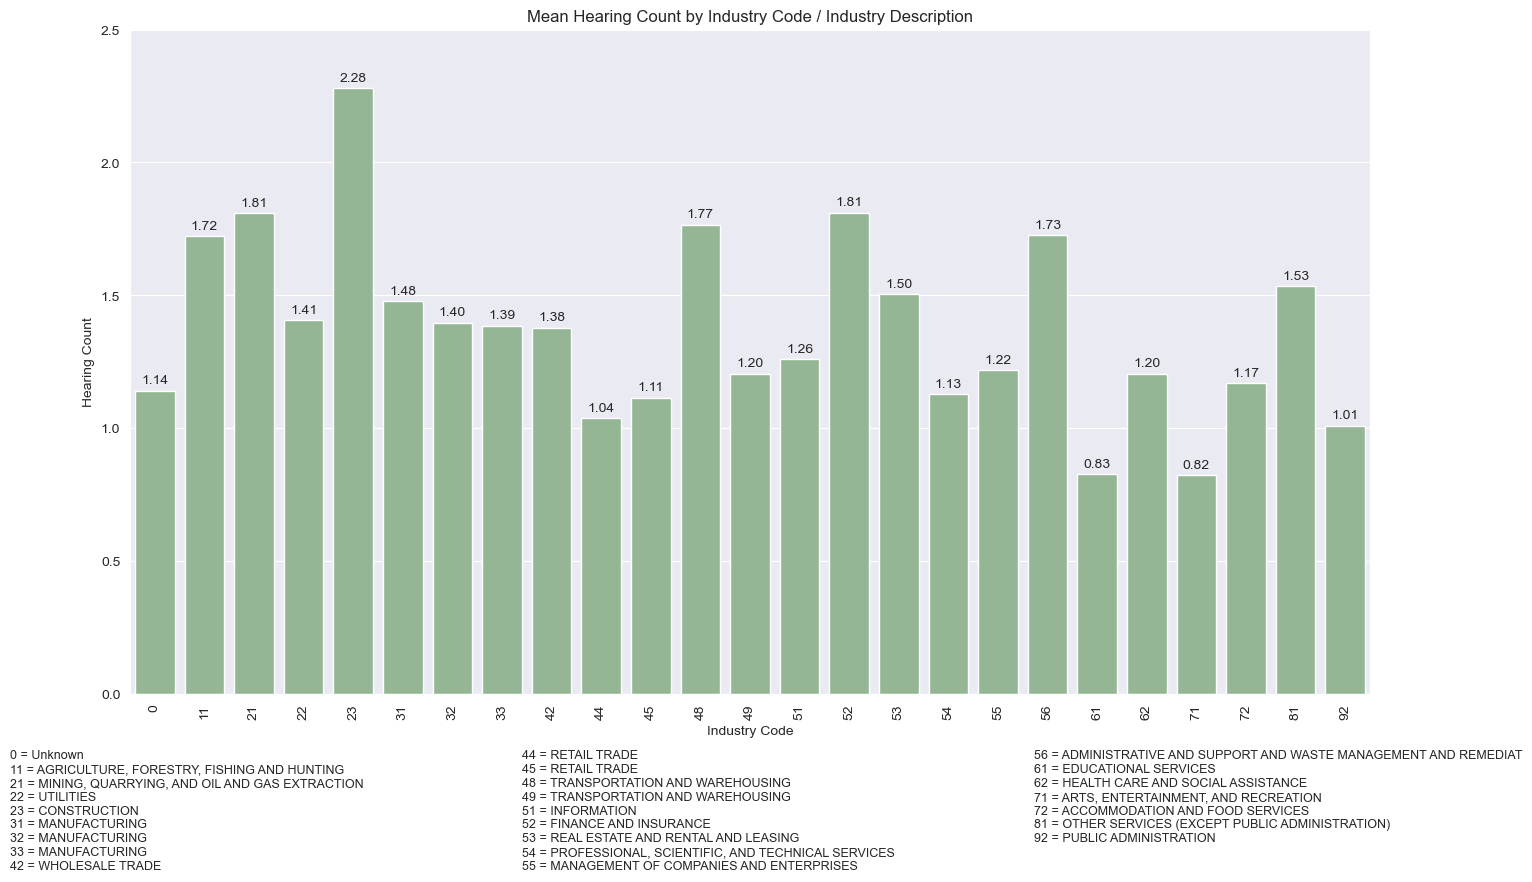

In [9]:
import math

sns.barplot(data=WC_data_clean, x='Industry Code',
            y='Hearing Count',
            errorbar=None,
            color='darkseagreen')

plt.title('Mean Hearing Count by Industry Code / Industry Description')
plt.xticks(rotation=90)
plt.ylim(0,2.5)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

industry_lookup = (
    WC_data_clean[['Industry Code', 'Industry Code Description']]
    .dropna()
    .drop_duplicates()
    .sort_values('Industry Code')
)

lookup_list = [
    f"{int(code)} = {desc}"
    for code, desc in zip(
        industry_lookup['Industry Code'],
        industry_lookup['Industry Code Description']
    )
]

n_cols = 3
rows_per_col = math.ceil(len(lookup_list) / n_cols)

col1 = "\n".join(lookup_list[:rows_per_col])
col2 = "\n".join(lookup_list[rows_per_col:rows_per_col * 2])
col3 = "\n".join(lookup_list[rows_per_col * 2:])

plt.gcf().set_size_inches(16, 8)    
plt.subplots_adjust(bottom=0.05)    

plt.figtext(0.05, -0.02, col1, ha='left', va='top', fontsize=9)
plt.figtext(0.37, -0.02, col2, ha='left', va='top', fontsize=9)
plt.figtext(0.69, -0.02, col3, ha='left', va='top', fontsize=9)

plt.show()

### Industry Characteristics Summary
2.1 Hearing counts vary meaningfully across industry codes. Construction (23) has the highest mean at 2.28, followed by Health Care and Social Assistance (62) and Mining (21), both at 1.81, and Transportation and Warehousing (48) at 1.77. On the lower end, Educational Services (61) averages 0.83 and Management of Companies and Enterprises (55) averages 0.82 — the two lowest among all classified industries. The pattern broadly suggests that industries involving physical labor and higher injury risk tend to generate more hearings, while service- and office-oriented industries tend to generate fewer.

2.2 Claims with an unknown or missing industry classification (code 0) average 1.14 hearings, which falls in the lower-middle range of the distribution and is well below high-activity industries like Construction and Mining. This suggests that missing industry data does not inflate hearing counts and is unlikely to be a confounding factor in the analysis.

### 3. Claim Characteristics
This issue explores whether claim-specific factors are associated with higher hearing counts.

- **Claim Injury Type or Claim Type** 
- **Attorney Involvement or ADR** 
- **Claim Status or Process Stage** 

#### 3.1 Claim Injury Type and Claim Type
Does claim injury type or claim type affect hearing frequency?

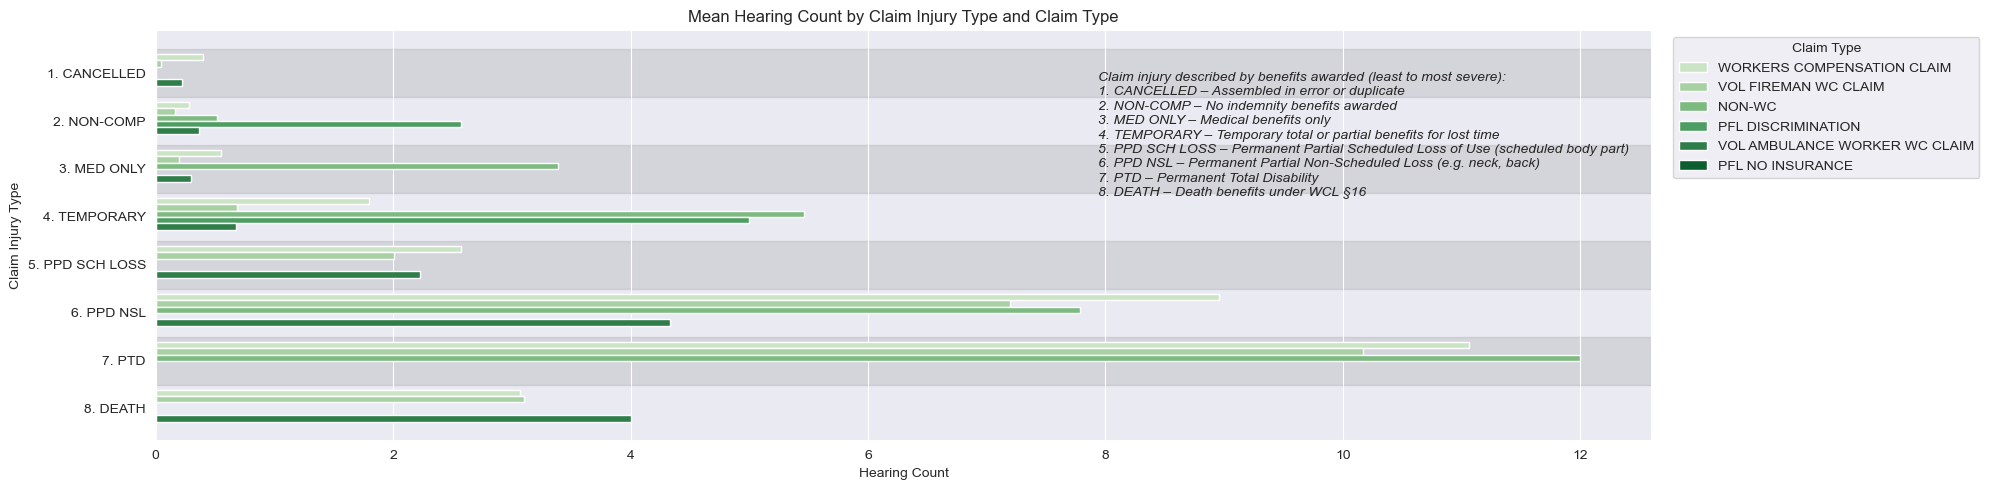

In [10]:
injury_type_order = ['1. CANCELLED','2. NON-COMP','3. MED ONLY','4. TEMPORARY','5. PPD SCH LOSS','6. PPD NSL','7. PTD','8. DEATH']


sns.barplot(data=WC_data_clean, x='Hearing Count', 
            y='Claim Injury Type',
            hue='Claim Type',
            errorbar=None,
            palette=sns.color_palette('Greens', n_colors=7)[1:],
            order=injury_type_order)

plt.title('Mean Hearing Count by Claim Injury Type and Claim Type')
plt.legend(title='Claim Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

ax = plt.gca()  
ax.text(0.63, 0.90,
    "Claim injury described by benefits awarded (least to most severe):\n"
    "1. CANCELLED – Assembled in error or duplicate\n"
    "2. NON-COMP – No indemnity benefits awarded\n"
    "3. MED ONLY – Medical benefits only\n"
    "4. TEMPORARY – Temporary total or partial benefits for lost time\n"
    "5. PPD SCH LOSS – Permanent Partial Scheduled Loss of Use (scheduled body part)\n"
    "6. PPD NSL – Permanent Partial Non-Scheduled Loss (e.g. neck, back)\n"
    "7. PTD – Permanent Total Disability\n"
    "8. DEATH – Death benefits under WCL §16",
    fontsize=10, style='italic', va='top', transform=ax.transAxes)


ax = plt.gca()

for i in range(len(ax.get_yticklabels())):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.2, zorder=0)

plt.show()

Hearing frequency is driven primarily by injury severity — PTD averages up to 12 hearings and PPD NSL up to 8.95. Claim type also matters: VOL FIREMAN WC CLAIM consistently outpaces WORKERS COMPENSATION CLAIM within the same injury type (e.g. PTD: 12.00 vs 10.17), while CANCELLED, NON-COMP, and MED ONLY remain near-zero across all claim types.

#### 3.2 Claim Injury Type and Claim Type
Is attorney involvement or ADR associated with higher hearing counts?

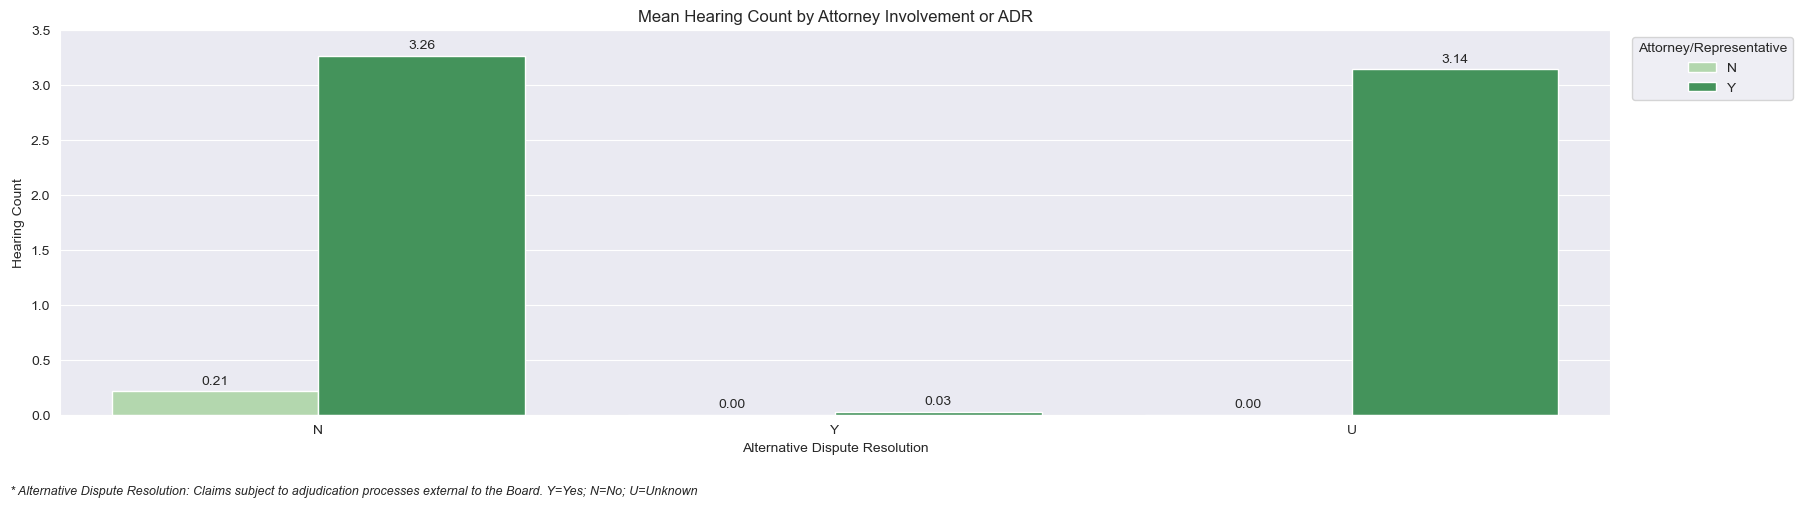

In [11]:
sns.barplot(data=WC_data_clean, x='Alternative Dispute Resolution',
            y='Hearing Count',
            hue='Attorney/Representative',
            errorbar=None,
            palette='Greens',
)

plt.title('Mean Hearing Count by Attorney Involvement or ADR')
plt.ylim(0,3.5)
plt.legend(title='Attorney/Representative', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.figtext(0.1, -0.05, 
    '* Alternative Dispute Resolution: Claims subject to adjudication processes external to the Board. '
    'Y=Yes; N=No; U=Unknown', 
    fontsize=9, style='italic')

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

Claims not subject to ADR (N) average 3.26 hearings with attorney representation, compared to near-zero (0.21) without. ADR cases (Y) show virtually no hearings regardless of representation, suggesting these cases may be resolved outside of board proceedings. U (Unknown) mirrors the N pattern, suggesting those cases likely follow standard board proceedings.

#### 3.3 Claim Status and Processing Stage
Does claim status or process stage influence the number of hearings?

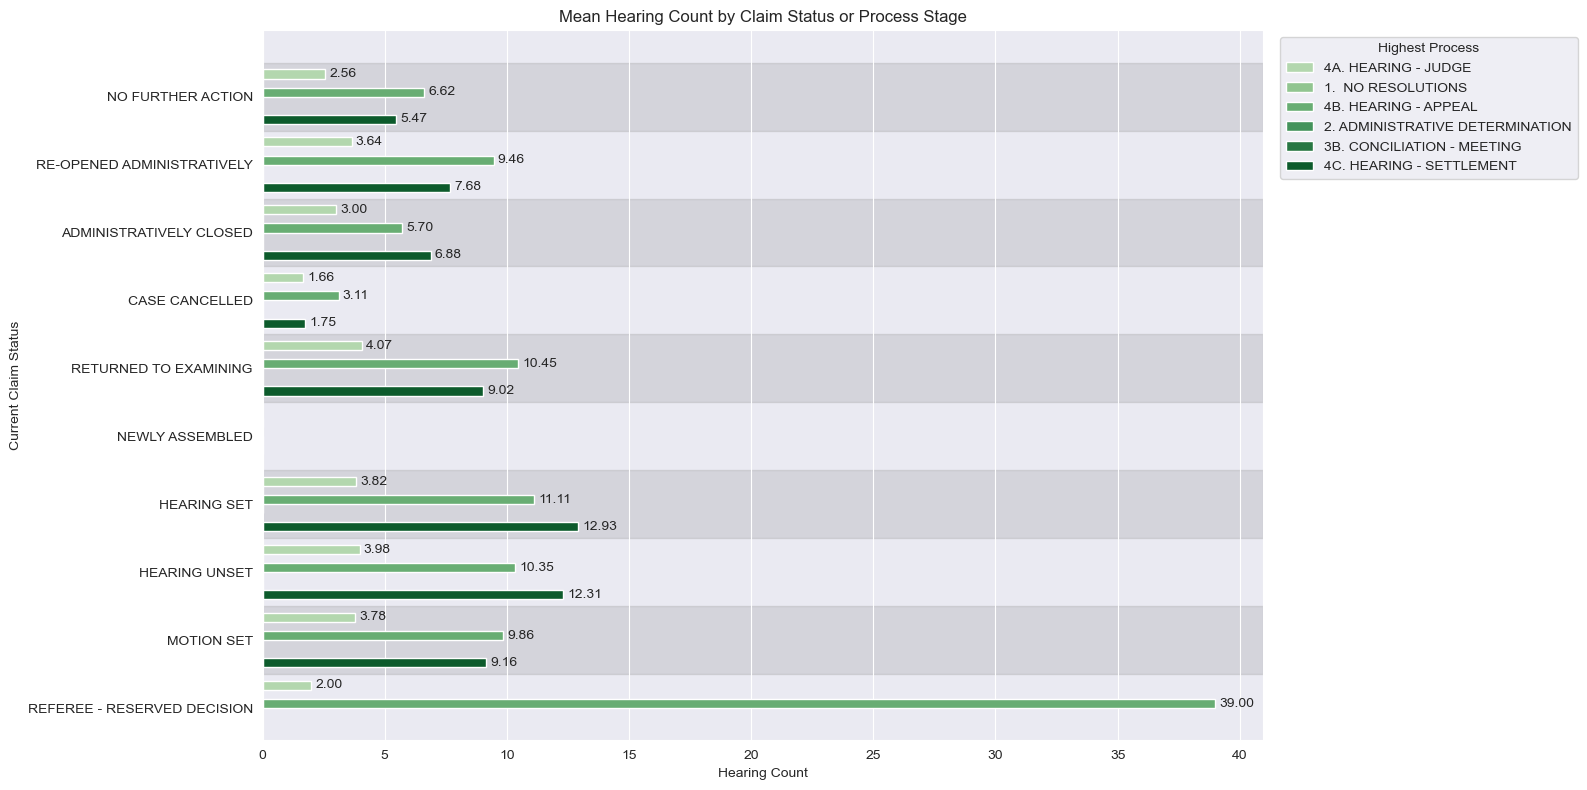

In [12]:
plt.gcf().set_size_inches(16, 8)

sns.barplot(data=WC_data_clean, x='Hearing Count',
            y='Current Claim Status',
            hue='Highest Process',
            errorbar=None,
            palette=sns.color_palette('Greens', n_colors=8)[2:]
)

plt.title('Mean Hearing Count by Claim Status or Process Stage')

ax = plt.gca()

for i in range(len(ax.get_yticklabels())):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.2, zorder=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3,
                 labels=[f'{v:.2f}' if v > 0.01 else '' for v in container.datavalues])

plt.legend(title='Highest Process', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plt.show()

Claim status and process stage both influence hearing frequency. Active statuses such as HEARING SET, HEARING UNSET, and MOTION SET average 10–13 hearings when claims reach settlement or conciliation stages, while earlier statuses like NEWLY ASSEMBLED and CASE CANCELLED show minimal hearing activity. Within each status, claims escalating to higher process stages consistently show higher average hearing counts, with REFEREE - RESERVED DECISION averaging 39.00 hearings at the highest end.

### Claim Characteristics Summary
Claim-specific factors are strongly associated with hearing frequency across all three dimensions. Injury severity is the clearest driver — PTD and PPD NSL average up to 12 and 8.95 hearings while less severe injuries remain near zero. Attorney representation is also associated with higher counts (3.26 vs 0.21 without), while ADR cases show virtually no hearings. Finally, active claim statuses such as HEARING SET and MOTION SET average 10–13 hearings at higher process stages, with REFEREE - RESERVED DECISION reaching 39.00 — the highest observed.

## Overall Summary

### Factors with the Strongest Association with Hearing Counts
Claim-specific characteristics show the strongest association with hearing counts. Injury severity is the clearest driver — PTD claims average 11.06 hearings and PPD NSL averages 8.95, while less severe injury types remain near zero. Process stage compounds this further, with Referee Reserved Decision claims averaging 39.00 hearings — the highest observed in the entire analysis.

### Factors with a Moderate Association
Attorney representation adds an additional layer, with represented claims averaging 3.26 hearings compared to 0.21 without, while ADR cases average near zero regardless of representation. Industry characteristics provide the next strongest signal — Construction (23) averages 2.28 hearings while Educational Services (61) averages 0.83, nearly a 3x difference, with physically demanding industries consistently averaging more hearings than service-oriented ones.

### Factors with a Weak or Negligible Association
Demographic characteristics show the weakest association overall. Age shows the most variation with hearing counts peaking in the 40s (1.54), while gender shows almost none with female (1.28) and male (1.25) claimants averaging nearly identical counts. Location falls in between, with NYC metro counties and districts consistently averaging more hearings than upstate counterparts.

**Overall, claim-specific characteristics provide the strongest and most actionable signal for understanding what drives hearing activity, suggesting that targeted interventions in these areas could meaningfully reduce administrative burden for the Workers' Compensation Board.**